#1 - Import Saved Training, Validation, Testing Datas

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import sklearn
import joblib
import os
import random
import urllib.request
import zipfile

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("All seeds set to", SEED)

All seeds set to 42


In [4]:
X_train = np.load("X_train.npy")
X_val   = np.load("X_val.npy")
X_test  = np.load("X_test.npy")
y_train = np.load("y_train.npy")
y_val   = np.load("y_val.npy")
y_test  = np.load("y_test.npy")

ACTIVITY_NAMES = [
    "Walking", "Walking Upstairs", "Walking Downstairs",
    "Sitting", "Standing", "Laying"
]

N_CLASSES    = 6
N_TIMESTEPS  = 128
N_CHANNELS   = 9

print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)
print("y_train:", y_train.shape)
print("y_val:  ", y_val.shape)
print("y_test: ", y_test.shape)

X_train: (6249, 128, 9)
X_val:   (1103, 128, 9)
X_test:  (2947, 128, 9)
y_train: (6249,)
y_val:   (1103,)
y_test:  (2947,)


In [7]:
import keras
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout, BatchNormalization
from keras.optimizers import Adam

In [9]:
import tensorflow as tf
print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


#2 - Build MLP Model

In [10]:
def build_model(dropout=0.2, unit_1=256, unit_2=128, learning_rate=0.001):
    model = Sequential(name="mlp_baseline")

    # Add Flatten Layer
    model.add(Flatten(input_shape=(N_TIMESTEPS, N_CHANNELS)))

    # Hidden Layer - 1
    model.add(Dense(unit_1, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(dropout))

    # Hidden Layer - 2
    model.add(Dense(unit_2, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(dropout))

    # Output Layer
    model.add(Dense(N_CLASSES, activation='softmax'))

    # compile with Adam optimiser and loss = sparse_categorical_crossentropy
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [11]:
model = build_model()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [12]:
model.summary()

Model: "mlp_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 330,374 (1.26 MB)

 Trainable params: 329,606 (1.26 MB)

 Non-trainable params: 768 (3.00 KB)

In [17]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

In [18]:
checkpoint_cb = ModelCheckpoint(
    filepath='best_model.keras',
    monitor='val_loss',
    mode='min',                     # 'min' for loss, 'max' for accuracy
    save_best_only=True,            # Only save when performance improves
    verbose=1
)

In [19]:
early_stopping_cb = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

In [20]:
reduce_lr_cb = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

In [21]:
callbacks = [early_stopping_cb, reduce_lr_cb, checkpoint_cb]

#3 - Train MLP Model

In [22]:
import time

In [23]:
start_time = time.time()

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=64,
    epochs=100,
    callbacks=callbacks,
    verbose=1
)

training_time = time.time() - start_time
print(f"\nTraining time: {training_time:.1f} seconds")

Epoch 1/100
83/98 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9741 - loss: 0.0647
Epoch 1: val_loss improved from None to 0.10092, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9690 - loss: 0.0709 - val_accuracy: 0.9519 - val_loss: 0.1009 - learning_rate: 2.5000e-04
Epoch 2/100
79/98 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9747 - loss: 0.0594
Epoch 2: val_loss did not improve from 0.10092
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9715 - loss: 0.0660 - val_accuracy: 0.9547 - val_loss: 0.1014 - learning_rate: 2.5000e-04
Epoch 3/100
95/98 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9751 - loss: 0.0590
Epoch 3: val_loss did not improve from 0.10092
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9728 - loss: 0.0648 - val_accuracy: 0.9538 - val_loss: 0.1022 - learning_rate: 2.5000e-04
Epoch 4/100
97/98 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9732 - loss: 0.0589
Epo

#4 - Plot training curves

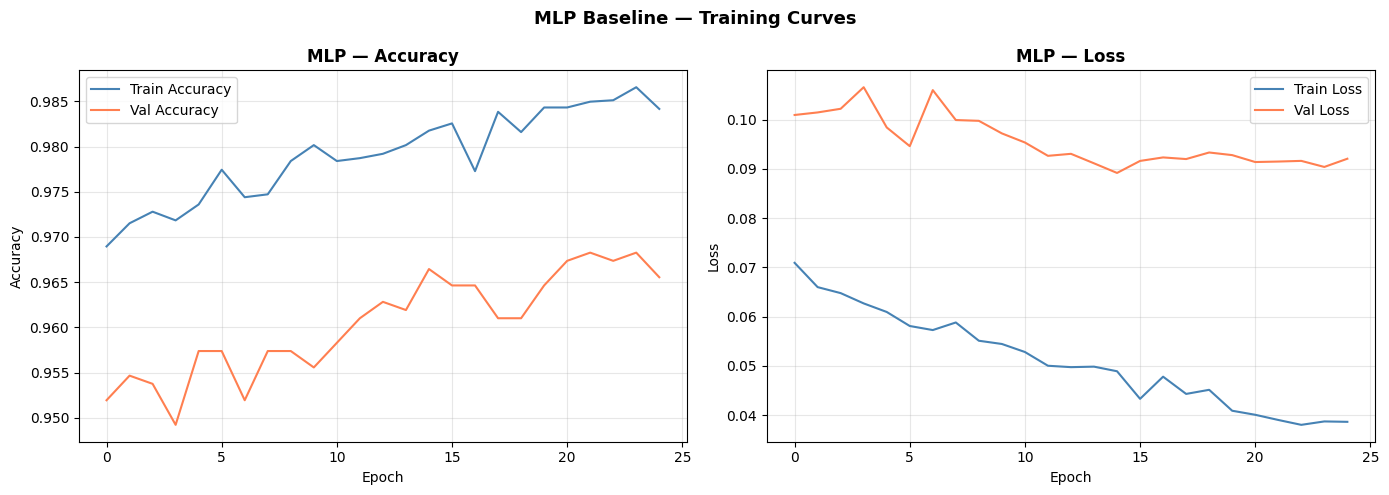

Best val_accuracy : 0.9683
Best val_loss     : 0.0892
Stopped at epoch  : 25


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train Accuracy', color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   color='coral')
axes[0].set_title('MLP — Accuracy', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'],     label='Train Loss', color='steelblue')
axes[1].plot(history.history['val_loss'], label='Val Loss',   color='coral')
axes[1].set_title('MLP — Loss', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('MLP Baseline — Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()

os.makedirs('reports/figures', exist_ok=True)
plt.savefig('reports/figures/mlp_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Best val_accuracy : {max(history.history['val_accuracy']):.4f}")
print(f"Best val_loss     : {min(history.history['val_loss']):.4f}")
print(f"Stopped at epoch  : {len(history.history['loss'])}")

In [26]:
from tensorflow.keras.models import load_model

mlp_model = load_model('best_model.keras')

mlp_model.summary()

Model: "mlp_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 989,588 (3.77 MB)

 Trainable params: 329,606 (1.26 MB)

 Non-trainable params: 768 (3.00 KB)

 Optimizer params: 659,214 (2.51 MB)

In [29]:
from sklearn.metrics import classification_report, f1_score, confusion_matrix

In [28]:
y_pred_probs = mlp_model.predict(X_val)
y_pred       = np.argmax(y_pred_probs, axis=1)

val_accuracy = np.mean(y_pred == y_val)
val_f1_macro = f1_score(y_val, y_pred, average='macro')

print(f"Validation Accuracy : {val_accuracy:.4f}")
print(f"Validation Macro F1 : {val_f1_macro:.4f}")
print()
print("Per-class report:")
print(classification_report(y_val, y_pred, target_names=ACTIVITY_NAMES))

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
Validation Accuracy : 0.9665
Validation Macro F1 : 0.9687

Per-class report:
                    precision    recall  f1-score   support

           Walking       1.00      1.00      1.00       184
  Walking Upstairs       0.99      0.99      0.99       161
Walking Downstairs       1.00      0.99      1.00       148
           Sitting       0.91      0.90      0.91       193
          Standing       0.91      0.92      0.92       206
            Laying       1.00      1.00      1.00       211

          accuracy                           0.97      1103
         macro avg       0.97      0.97      0.97      1103
      weighted avg       0.97      0.97      0.97      1103



#5 - Saving MLP Results

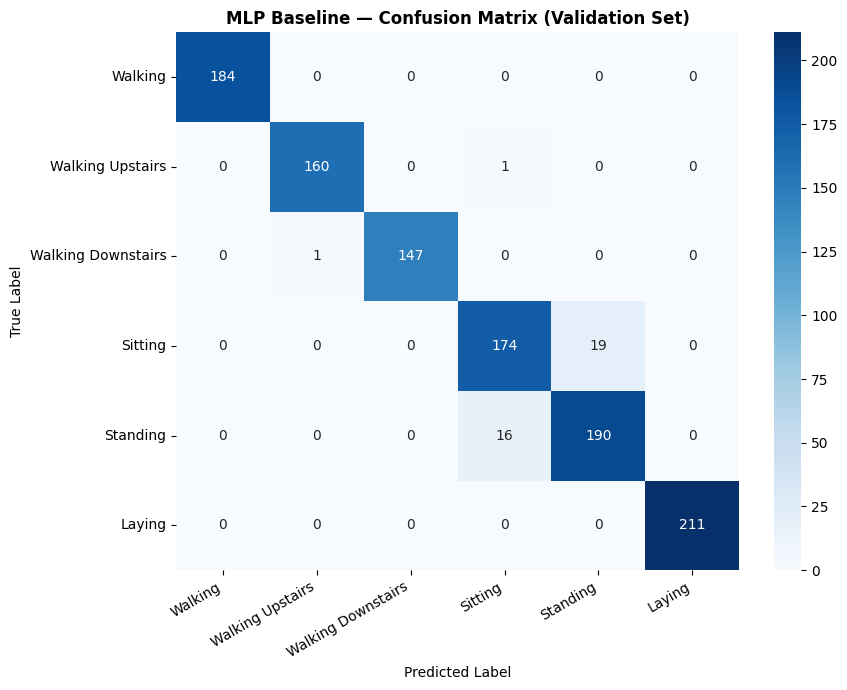

In [30]:
os.makedirs("reports/figures", exist_ok=True)

cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True, fmt='d',
    cmap='Blues',
    xticklabels=ACTIVITY_NAMES,
    yticklabels=ACTIVITY_NAMES
)
plt.title('MLP Baseline — Confusion Matrix (Validation Set)',
          fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('reports/figures/mlp_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
os.makedirs("artifacts/results", exist_ok=True)

mlp_results = {
    "model"         : "MLP",
    "total_params"  : mlp_model.count_params(),
    "val_accuracy"  : round(float(val_accuracy), 4),
    "val_f1_macro"  : round(float(val_f1_macro), 4),
    "training_time" : round(training_time, 1),
    "epochs_run"    : len(history.history['loss']),
    "train_acc_curve": [round(v, 4) for v in history.history['accuracy']],
    "val_acc_curve"  : [round(v, 4) for v in history.history['val_accuracy']],
    "train_loss_curve": [round(v, 4) for v in history.history['loss']],
    "val_loss_curve"  : [round(v, 4) for v in history.history['val_loss']],
}

import json
with open("artifacts/results/mlp_results.json", "w") as f:
    json.dump(mlp_results, f, indent=2)

print("Results saved to artifacts/results/mlp_results.json")
print()
print("=" * 45)
print("MLP BASELINE SUMMARY")
print("=" * 45)
print(f"Total Parameters : {mlp_model.count_params():,}")
print(f"Val Accuracy     : {val_accuracy:.4f}")
print(f"Val Macro F1     : {val_f1_macro:.4f}")
print(f"Training Time    : {training_time:.1f}s")
print(f"Epochs Run       : {len(history.history['loss'])}")
print("=" * 45)

Results saved to artifacts/results/mlp_results.json

MLP BASELINE SUMMARY
Total Parameters : 330,374
Val Accuracy     : 0.9665
Val Macro F1     : 0.9687
Training Time    : 11.9s
Epochs Run       : 25


In [ ]:
os.makedirs("artifacts/models", exist_ok=True)
mlp_model.save("artifacts/models/mlp_best.keras")
print("Model saved to artifacts/models/mlp_best.keras")


MLP BASELINE SUMMARY

* Total Parameters : 330,374
* Val Accuracy     : 0.9665
* Val Macro F1     : 0.9687
* Training Time    : 11.9s
* Epochs Run       : 25